In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from config import ExperimentConfig
from data import generate_synthetic_data, compute_noise_summary
from training import fit_multi_ic_pinn, fit_sigma_ar1_repeated
from utils import set_seed, mean_and_ci
from diagnostics import plot_percentage_error_vs_state

In [4]:
# ============================================================
# Setup
# ============================================================
N0_list = (0.10, 0.12, 0.13, 0.09)
cfg = ExperimentConfig(N0_list=N0_list)
device = torch.device(cfg.device)

set_seed(cfg.seed_torch, cfg.seed_numpy)

# ============================================================
# Generate data
# ============================================================
data = generate_synthetic_data(cfg, device)

t_obs = data["t_obs"]
t_plot = data["t_plot"]
N_grid = data["N_grid"]
y_true_all = data["y_true_all"]
y_data_all = data["y_data_all"]
noise_all = data["noise_all"]
G_grid_true = data["G_grid_true"]
sigma_true_grid = data["sigma_true_grid"]

n_ics = len(cfg.N0_list)

In [3]:
# ============================================================
# Noise summary
# ============================================================
stats = compute_noise_summary(
    y_true_all=y_true_all,
    y_data_all=y_data_all,
    noise_sig_coeff=cfg.noise_sig_coeff,
    gamma=cfg.gamma,
)

print("\nNoise summary")
print("-------------")
print(f"rho_true: {cfg.rho_true:.4f}")
print(f"mean signed noise: {stats['noise_np'].mean():.6e}")
print(f"std signed noise : {stats['noise_np'].std(ddof=1):.6e}")
print(f"mean abs noise   : {stats['abs_noise_np'].mean():.6e}")
print(f"RMSE noise       : {np.sqrt(np.mean(stats['noise_np']**2)):.6e}")
print(f"mean sigma_true  : {stats['sigma_true_obs_np'].mean():.6e}")


Noise summary
-------------
rho_true: 0.5000
mean signed noise: -5.465920e-04
std signed noise : 6.854752e-02
mean abs noise   : 4.770684e-02
RMSE noise       : 6.819177e-02
mean sigma_true  : 6.299866e-02


In [5]:
import copy
import math
import numpy as np
import torch
import matplotlib.pyplot as plt


# -----------------------------
# Small helpers
# -----------------------------
def set_seed(seed: int = 20260316):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def clone_cfg(cfg, **updates):
    new_cfg = copy.deepcopy(cfg)
    for k, v in updates.items():
        setattr(new_cfg, k, v)
    return new_cfg


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _squeeze_last(x):
    x = _to_numpy(x)
    if x.ndim > 0 and x.shape[-1] == 1:
        x = np.squeeze(x, axis=-1)
    return x


def _get_noise_and_truth(data_dict):
    y_true = _squeeze_last(data_dict["y_true_all"])   # [n_traj, T]
    y_data = _squeeze_last(data_dict["y_data_all"])   # [n_traj, T]
    noise = _squeeze_last(data_dict["noise_all"])     # [n_traj, T]
    t_obs = _squeeze_last(data_dict["t_obs"])         # [T]
    return t_obs, y_true, y_data, noise


def _sigma_from_truth(y_true, noise_sig_coeff, gamma):
    return noise_sig_coeff * np.power(np.clip(y_true, 0.0, None), gamma)


def _decorrelated_residuals(noise, rho):
    """
    noise: [n_traj, T]
    returns eta_tilde of same shape, where
      eta_tilde[:, 0] = noise[:, 0]
      eta_tilde[:, k] = (noise[:, k] - rho * noise[:, k-1]) / sqrt(1-rho^2),  k>=1
    """
    noise = np.asarray(noise)
    out = np.zeros_like(noise)
    out[:, 0] = noise[:, 0]

    denom = max(1.0 - rho**2, 1e-12)
    rootfac = math.sqrt(denom)
    out[:, 1:] = (noise[:, 1:] - rho * noise[:, :-1]) / rootfac
    return out


def _innovations(noise, rho):
    """
    innovation dev_k = eta_k - rho eta_{k-1}, for k>=1
    """
    return noise[:, 1:] - rho * noise[:, :-1]


# -----------------------------
# 1) Binned variance of innovations
# -----------------------------
def plot_binned_innovation_variance(
    cfg,
    device="cpu",
    seed=20260316,
    n_bins=6,
    use_observed_for_binning=True,
    ax=None,
):
    """
    Reproduces the bar-style plot of empirical binned variance of
    dev_k = eta_k - rho * eta_{k-1}, together with the theory
        Var(dev_k | N) = (1-rho^2) * sigma(N)^2
    for sigma(N) = c_sigma * N^gamma.
    """
    set_seed(seed)
    data = generate_synthetic_data(cfg, device=device)
    t_obs, y_true, y_data, noise = _get_noise_and_truth(data)

    rho = float(cfg.rho_true)
    innovations = _innovations(noise, rho)  # [n_traj, T-1]

    if use_observed_for_binning:
        N_for_bins = np.clip(y_data[:, 1:], 0.0, 0.999999)
    else:
        N_for_bins = np.clip(y_true[:, 1:], 0.0, 0.999999)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_ids = np.minimum((N_for_bins * n_bins).astype(int), n_bins - 1)

    counts = np.zeros(n_bins, dtype=int)
    variances = np.zeros(n_bins, dtype=float)

    for b in range(n_bins):
        vals = innovations[bin_ids == b]
        counts[b] = vals.size
        variances[b] = np.var(vals, ddof=1) if vals.size > 1 else 0.0

    max_count = max(counts.max(), 1)
    full_bin_width = bin_edges[1] - bin_edges[0]
    bar_widths = full_bin_width * counts / max_count

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    else:
        fig = ax.figure

    # Theory
    N_grid = np.linspace(0.0, 1.0, 400)
    sigma_grid = cfg.noise_sig_coeff * (N_grid ** cfg.gamma)
    theory = (1.0 - rho**2) * sigma_grid**2
    ax.plot(N_grid, theory, "--", linewidth=2, label=r"$(1-\rho^2)\sigma(N)^2$")

    # Variable-width bars centered in each bin
    ax.bar(
        bin_centers,
        variances,
        width=bar_widths,
        align="center",
        alpha=0.65,
        label="Empirical binned variance",
    )

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(bottom=0.0)
    ax.set_xlabel(r"$N$")
    ax.set_ylabel(r"$\mathrm{Var}(\eta_k - \rho \eta_{k-1})$")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    return fig, ax


# -----------------------------
# 2) Lag-1 scatter of AR(1) residuals
# -----------------------------
def plot_lag1_noise_scatter(
    cfg,
    device="cpu",
    seed=20260316,
    ax=None,
    color_by="true",   # "true" or "observed"
):
    """
    Scatter plot of pairs (eta_{k-1}, eta_k), colored by N_k,
    with reference line eta_k = rho * eta_{k-1}.
    """
    set_seed(seed)
    data = generate_synthetic_data(cfg, device=device)
    _, y_true, y_data, noise = _get_noise_and_truth(data)

    x = noise[:, :-1].reshape(-1)
    y = noise[:, 1:].reshape(-1)

    if color_by == "observed":
        c = np.clip(y_data[:, 1:], 0.0, 1.0).reshape(-1)
        cbar_label = r"$N_k^{\mathrm{obs}}$"
    else:
        c = np.clip(y_true[:, 1:], 0.0, 1.0).reshape(-1)
        cbar_label = r"$N_k$"

    rho = float(cfg.rho_true)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.5))
    else:
        fig = ax.figure

    sc = ax.scatter(x, y, c=c, s=18, cmap="viridis")
    lim = max(np.max(np.abs(x)), np.max(np.abs(y)), 1e-3)
    lim *= 1.05
    ref = np.array([-lim, lim])
    ax.plot(ref, rho * ref, "--", linewidth=2, label=r"$\eta_k = \rho \eta_{k-1}$")

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(r"$\eta_{k-1}$")
    ax.set_ylabel(r"$\eta_k$")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(cbar_label)

    return fig, ax


# -----------------------------
# 3) |decorrelated residual| vs N
# -----------------------------
def plot_abs_decorrelated_residuals(
    cfg,
    device="cpu",
    seed=20260316,
    ax=None,
):
    """
    Plots three realizations of |eta_tilde|, where eta_tilde is the
    decorrelated residual, plus:
      E|eta_tilde| = sqrt(2/pi) sigma(N)
      empirical mean across realizations
    """
    set_seed(seed)
    data = generate_synthetic_data(cfg, device=device)
    _, y_true, _, noise = _get_noise_and_truth(data)

    rho = float(cfg.rho_true)
    eta_tilde = _decorrelated_residuals(noise, rho)
    abs_eta_tilde = np.abs(eta_tilde)

    # Use first trajectory's true state as x-axis if all have same dynamics shape,
    # otherwise average across trajectories.
    xN = y_true[0]
    sigma_true = _sigma_from_truth(xN, cfg.noise_sig_coeff, cfg.gamma)
    expected_abs = math.sqrt(2.0 / math.pi) * sigma_true
    empirical_mean = abs_eta_tilde.mean(axis=0)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    else:
        fig = ax.figure

    n_traj = abs_eta_tilde.shape[0]
    for i in range(n_traj):
        ax.plot(xN, abs_eta_tilde[i], marker="o", linewidth=1, markersize=3)

    ax.plot(
        xN,
        expected_abs,
        linestyle=":",
        linewidth=2.5,
        color="red",
        label=r"$\mathbb{E}[|\tilde{\eta}|]=\sqrt{2/\pi}\,\sigma(N)$",
    )
    ax.plot(
        xN,
        empirical_mean,
        linewidth=2.5,
        color="black",
        label=r"empirical mean $|\tilde{\eta}|$",
    )

    ax.set_xlabel(r"$N$")
    ax.set_ylabel(r"$|\tilde{\eta}|$")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    return fig, ax


# -----------------------------
# 4) Observation plot for a single rho
# -----------------------------
def plot_observations(
    cfg,
    device="cpu",
    seed=20260316,
    ax=None,
    time_scale=4.0,
):
    """
    Plots y_true(t) and all observed realizations y_obs^(i)(t).
    `time_scale` lets you mimic your TikZ relabeling:
      sample index 0..24 shown as 0,24,48,72,96 hours when time_scale=4.
    """
    set_seed(seed)
    data = generate_synthetic_data(cfg, device=device)
    t_obs, y_true, y_data, _ = _get_noise_and_truth(data)

    # convert model grid to displayed hours
    t_plot = t_obs * time_scale

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4.5))
    else:
        fig = ax.figure

    # True curve: use first realization since deterministic dynamics match per N0
    for i, N0 in enumerate(cfg.N0_list):
        label = r"$y_{\mathrm{true}}(t)$" if i == 0 else None
        ax.plot(t_plot, y_true[i], linewidth=2.5, color="red", label=label)

    for i in range(y_data.shape[0]):
        ax.plot(
            t_plot,
            y_data[i],
            marker="o",
            linewidth=1.8,
            markersize=4,
            label=rf"$y_{{\mathrm{{obs}}}}^{{({i+1})}}$",
        )

    ax.set_xlabel("time (hours)")
    ax.set_ylabel(r"$y$")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, loc="lower right")
    return fig, ax


# -----------------------------
# 5) Side-by-side rho comparison
# -----------------------------
def plot_observation_comparison(
    cfg,
    rhos=(0.0, 0.8),
    device="cpu",
    seed=20260316,
    time_scale=4.0,
):
    """
    Creates the two observation plots corresponding to rho=0 and rho=0.8.
    """
    fig, axes = plt.subplots(1, len(rhos), figsize=(7 * len(rhos), 4.5), sharey=True)

    if len(rhos) == 1:
        axes = [axes]

    for ax, rho in zip(axes, rhos):
        cfg_rho = clone_cfg(cfg, rho_true=float(rho))
        plot_observations(cfg_rho, device=device, seed=seed, ax=ax, time_scale=time_scale)
        ax.set_title(rf"$\rho={rho}$")

    fig.tight_layout()
    return fig, axes

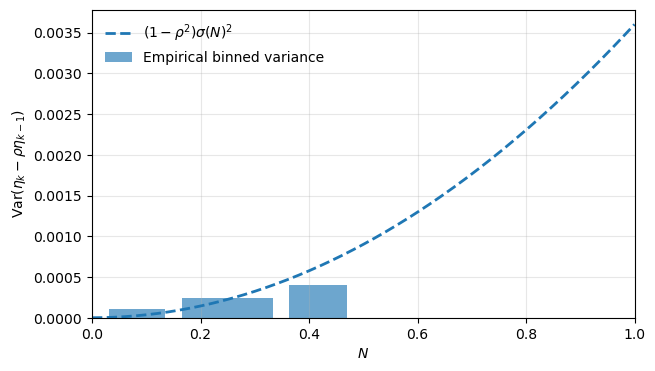

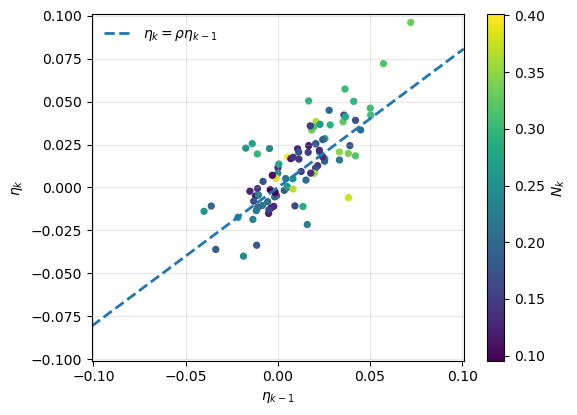

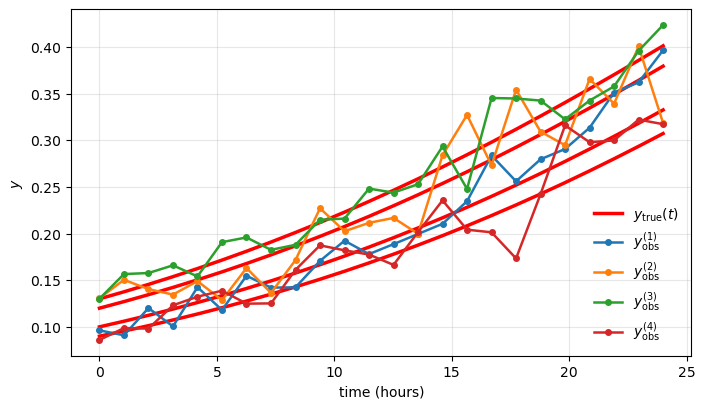

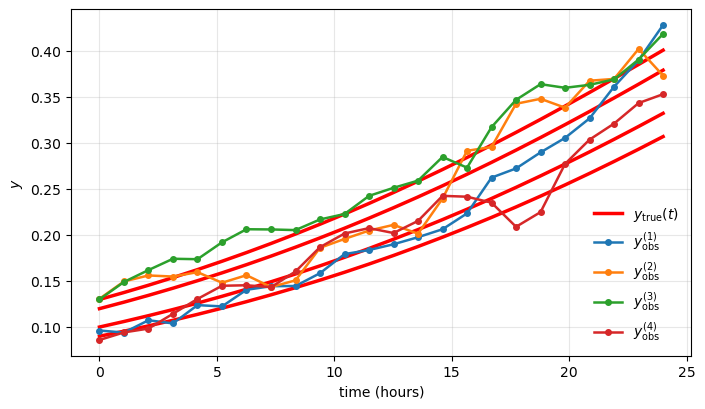

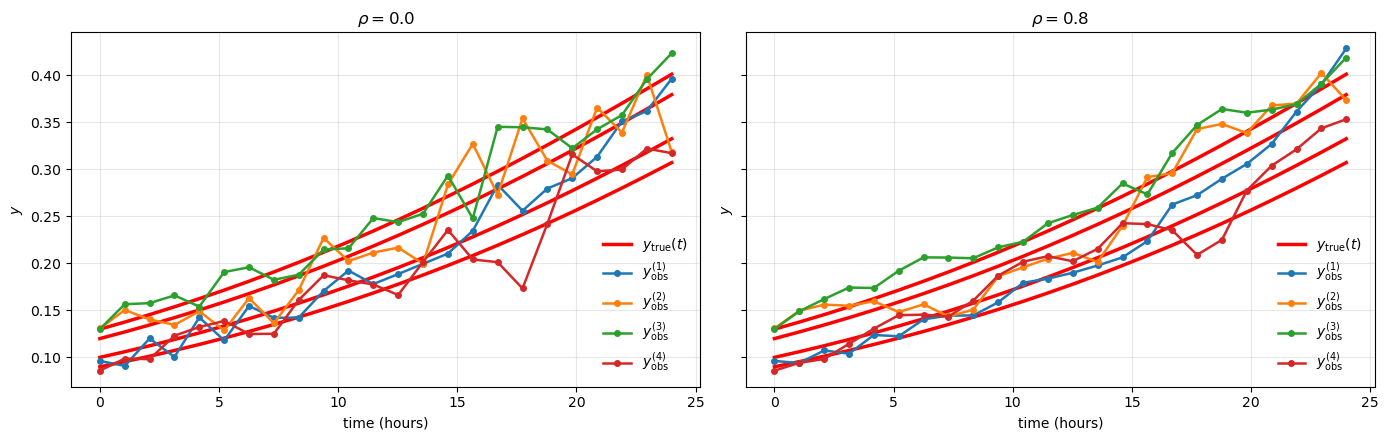

In [ ]:
# 1) binned innovation variance
cfg1 = clone_cfg(cfg, r_true=0.3, rho_true=0.8)
plot_binned_innovation_variance(cfg1, device=device, n_bins=6)
plt.show()

# 2) lag-1 scatter
cfg2 = clone_cfg(cfg, r_true=0.25, rho_true=0.8)
plot_lag1_noise_scatter(cfg2, device=device, color_by="true")
plt.show()

# 3) |decorrelated residual| vs N
cfg3 = clone_cfg(cfg, r_true=0.25, rho_true=0.8)
plot_abs_decorrelated_residuals(cfg3, device=device)
plt.show()

# 4) observations for rho = 0
cfg4 = clone_cfg(cfg, r_true=0.25, rho_true=0.0)
plot_observations(cfg4, device=device)
plt.show()

# 5) observations for rho = 0.8
cfg5 = clone_cfg(cfg, r_true=0.25, rho_true=0.8)
plot_observations(cfg5, device=device)
plt.show()

# optional side-by-side comparison
plot_observation_comparison(clone_cfg(cfg, r_true=0.25), rhos=(0.0, 0.8), device=device)
plt.show()